# Normal Probability Distribution

## 1. Definition

## 2. Intuition


## 3. Parameter

## 4. Support

## 5. Probability Mass Function


## 6. Cumulative Distribution Function


## 7. Moments

## 8. NumPy Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import erf, gammainc, gammaln, betainc, betaln


def validate_sample_size(size):
    if not isinstance(size, (int, np.integer)):
        raise TypeError("size must be an integer.")

    if size < 1:
        raise ValueError("size must be at least 1.")

In [2]:
class Normal:
    """
    Normal distribution with mean mu and standard deviation sigma.
    """

    def __init__(self, mu: float = 0.0, sigma: float = 1.0):
        if not np.isfinite(mu):
            raise ValueError("mu must be finite.")

        if not np.isfinite(sigma) or sigma <= 0:
            raise ValueError("sigma must be finite and greater than 0.")

        self.mu = float(mu)
        self.sigma = float(sigma)

    def pdf(self, x):
        x = np.asarray(x)

        z = (x - self.mu) / self.sigma

        return (
            np.exp(-0.5 * z**2)
            / (self.sigma * np.sqrt(2 * np.pi))
        )

    def cdf(self, x):
        x = np.asarray(x)

        z = (
            (x - self.mu)
            / (self.sigma * np.sqrt(2))
        )

        return 0.5 * (1 + erf(z))

    def mean(self):
        return self.mu

    def variance(self):
        return self.sigma**2

    def sample(self, size=1, random_state=None):
        validate_sample_size(size)

        rng = np.random.default_rng(random_state)

        return rng.normal(
            loc=self.mu,
            scale=self.sigma,
            size=size,
        )

    def plot(self, num_points=500, figsize=(10, 4)):
        x = np.linspace(
            self.mu - 4 * self.sigma,
            self.mu + 4 * self.sigma,
            num_points,
        )

        fig, axes = plt.subplots(1, 2, figsize=figsize)

        axes[0].plot(x, self.pdf(x))
        axes[0].axvline(
            self.mean(),
            linestyle="--",
            label=f"Mean = {self.mean():.2f}",
        )
        axes[0].set_title("Normal PDF")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("Density")
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(x, self.cdf(x))
        axes[1].set_title("Normal CDF")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("Cumulative probability")
        axes[1].set_ylim(-0.05, 1.05)
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

Normal PDF: [0.24197072 0.39894228 0.24197072]
Normal CDF: [0.15865525 0.5        0.84134475]


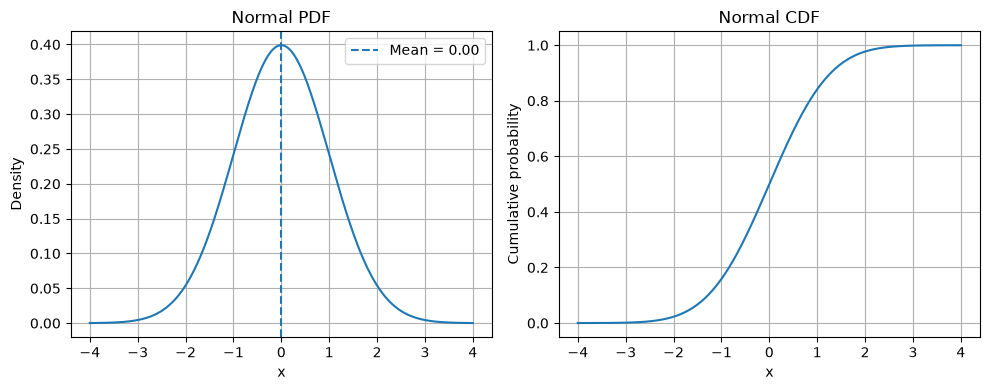

In [3]:
normal = Normal(mu=0, sigma=1)
print("Normal PDF:", normal.pdf([-1, 0, 1]))
print("Normal CDF:", normal.cdf([-1, 0, 1]))
normal.plot()